## setup

In [13]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from torch.utils.data import TensorDataset, DataLoader


In [7]:
import numpy as np

# Load feature arrays
X_list = []
for i in range(1, 10):
    X = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    X = X[:, None, :, :]      # Add channel dimension
    X_list.append(X)

# Combine into one dataset
X = np.concatenate(X_list, axis=0)

print("X shape:", X.shape)


# Load label arrays
y_list = []
for i in range(1, 10):
    y = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")
    y_list.append(y)

# Combine labels
y = np.concatenate(y_list, axis=0)

print("y shape:", y.shape)

X shape: (5184, 1, 22, 1001)
y shape: (5184,)


In [8]:
# input: (batch, 1, Chans, Samples)


class ATCNet(nn.Module):
    def __init__(
        self,
        nb_classes=4,
        Chans=22,
        Samples=1125,
        n_windows=5,
        attention="mha",
        eegn_F1=16,
        eegn_D=2,
        eegn_kernelSize=64,
        eegn_poolSize=7,
        eegn_dropout=0.3,
        tcn_depth=2,
        tcn_kernelSize=4,
        tcn_filters=32,
        tcn_dropout=0.3,
        tcn_activation="elu",
        fuse="average",
    ):
        super().__init__()

        self.n_windows = n_windows
        self.attention = attention
        self.fuse = fuse

        F2 = eegn_F1 * eegn_D

        ################################################## EEGNet Conv Block #################################################

        self.conv_temporal = nn.Conv2d(
            in_channels=1,
            out_channels=eegn_F1,
            kernel_size=(1, eegn_kernelSize),
            padding="same",
            bias=False,
        )

        self.bn1 = nn.BatchNorm2d(eegn_F1, eps=1e-3, momentum=0.01)

        self.conv_spatial = nn.Conv2d(
            in_channels=eegn_F1,
            out_channels=F2,
            kernel_size=(Chans, 1),
            groups=eegn_F1,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)

        self.pool1 = nn.AvgPool2d(kernel_size=(1, eegn_poolSize))
        self.drop1 = nn.Dropout(eegn_dropout)

        ################################################## Attention Blocks #################################################

        if attention == "mha":
            self.attention_blocks = nn.ModuleList([
                nn.MultiheadAttention(
                    embed_dim=F2,
                    num_heads=4,
                    batch_first=True,
                )
                for _ in range(n_windows)
            ])
        elif attention in ["se", "cbam"]:
            self.attention_blocks = nn.ModuleList([
                ChannelAttention(F2) for _ in range(n_windows)
            ])
        elif attention is None:
            self.attention_blocks = nn.ModuleList([
                nn.Identity() for _ in range(n_windows)
            ])
        else:
            raise ValueError(f"Unsupported attention type: {attention}")

        ################################################## TCN Blocks #################################################

        self.tcn_blocks = nn.ModuleList([
            TCNBlock(
                input_dim=F2,
                filters=tcn_filters,
                depth=tcn_depth,
                kernel_size=tcn_kernelSize,
                dropout=tcn_dropout,
                activation=tcn_activation,
            )
            for _ in range(n_windows)
        ])

        ################################################## Classifier #################################################

        if fuse == "average":
            self.classifiers = nn.ModuleList([
                nn.Linear(tcn_filters, nb_classes)
                for _ in range(n_windows)
            ])
        elif fuse == "concat":
            self.classifier = nn.Linear(tcn_filters * n_windows, nb_classes)
        else:
            raise ValueError("fuse must be 'average' or 'concat'")

    def _conv_features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)
        x = self.bn2(x)
        x = F.elu(x)

        x = self.pool1(x)
        x = self.drop1(x)

        # x: (batch, F2, 1, time)
        x = x[:, :, -1, :]          # (batch, F2, time)
        x = x.permute(0, 2, 1)      # (batch, time, F2)

        return x

    def _apply_attention(self, x, i):
        if self.attention == "mha":
            x, _ = self.attention_blocks[i](x, x, x)
            return x

        return self.attention_blocks[i](x)

    def forward(self, x):
        # x: (batch, 1, Chans, Samples)

        x = self._conv_features(x)      # (batch, time, F2)

        time_steps = x.shape[1]
        window_outputs = []

        for i in range(self.n_windows):
            start = i
            end = time_steps - self.n_windows + i + 1

            x_window = x[:, start:end, :]       # (batch, window_time, F2)

            x_window = self._apply_attention(x_window, i)

            x_window = self.tcn_blocks[i](x_window)

            x_window = x_window[:, -1, :]       # last sequence output

            if self.fuse == "average":
                x_window = self.classifiers[i](x_window)
                window_outputs.append(x_window)
            else:
                window_outputs.append(x_window)

        if self.fuse == "average":
            x = torch.stack(window_outputs, dim=0).mean(dim=0)
        else:
            x = torch.cat(window_outputs, dim=1)
            x = self.classifier(x)

        return x


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        hidden = max(1, channels // reduction)

        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        # x: (batch, time, channels)

        w = x.mean(dim=1)
        w = F.elu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w))
        w = w.unsqueeze(1)

        return x * w


class TCNBlock(nn.Module):
    def __init__(
        self,
        input_dim,
        filters=32,
        depth=2,
        kernel_size=4,
        dropout=0.3,
        activation="elu",
    ):
        super().__init__()

        self.blocks = nn.ModuleList()

        for i in range(depth):
            dilation = 2 ** i
            in_channels = input_dim if i == 0 else filters

            self.blocks.append(
                TCNResidualBlock(
                    in_channels=in_channels,
                    out_channels=filters,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                    activation=activation,
                )
            )

    def forward(self, x):
        # x: (batch, time, channels)

        x = x.permute(0, 2, 1)      # (batch, channels, time)

        for block in self.blocks:
            x = block(x)

        x = x.permute(0, 2, 1)      # (batch, time, filters)

        return x


class TCNResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout,
        activation="elu",
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation,
        )

        self.bn1 = nn.BatchNorm1d(out_channels, eps=1e-3, momentum=0.01)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation,
        )

        self.bn2 = nn.BatchNorm1d(out_channels, eps=1e-3, momentum=0.01)

        self.dropout = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels
            else nn.Identity()
        )

        self.padding = padding
        self.activation = activation

    def _act(self, x):
        if self.activation == "elu":
            return F.elu(x)
        elif self.activation == "relu":
            return F.relu(x)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

    def _chomp(self, x):
        if self.padding == 0:
            return x
        return x[:, :, :-self.padding]

    def forward(self, x):
        residual = self.downsample(x)

        out = self.conv1(x)
        out = self._chomp(out)
        out = self.bn1(out)
        out = self._act(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self._chomp(out)
        out = self.bn2(out)
        out = self._act(out)
        out = self.dropout(out)

        return out + residual

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)


## sweep

In [ ]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

X_cv = X.astype(np.float32)
y_cv = y.astype(np.int64)

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n_seen = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)

    return total_loss / max(n_seen, 1)


def predict(model, loader):
    model.eval()
    preds = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds.append(logits.argmax(dim=1).cpu().numpy())

    return np.concatenate(preds)


def objective(trial):
    eegn_dropout = trial.suggest_float("eegn_dropout", 0.2, 0.7)
    eegn_kernelSize = trial.suggest_categorical("eegn_kernelSize", [32, 64, 125])
    eegn_F1 = trial.suggest_categorical("eegn_F1", [4, 8, 16, 32])
    eegn_D = trial.suggest_categorical("eegn_D", [1, 2, 4])
    eegn_poolSize = trial.suggest_categorical("eegn_poolSize", [4, 7, 8])

    n_windows = trial.suggest_categorical("n_windows", [3, 5])
    attention = trial.suggest_categorical("attention", ["mha", "se", None])

    tcn_depth = trial.suggest_int("tcn_depth", 1, 3)
    tcn_kernelSize = trial.suggest_categorical("tcn_kernelSize", [3, 4, 5])
    tcn_filters = trial.suggest_categorical("tcn_filters", [16, 32, 64])
    tcn_dropout = trial.suggest_float("tcn_dropout", 0.2, 0.6)

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    max_epochs = 60
    patience = 10
    n_splits = 9

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv)):
        X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

        train_ds = TensorDataset(
            torch.from_numpy(X_tr),
            torch.from_numpy(y_tr),
        )

        valid_ds = TensorDataset(
            torch.from_numpy(X_va),
            torch.from_numpy(y_va),
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            drop_last=False,
        )

        valid_loader = DataLoader(
            valid_ds,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

        model = ATCNet(
            nb_classes=nb_classes,
            Chans=Chans,
            Samples=Samples,
            n_windows=n_windows,
            attention=attention,
            eegn_F1=eegn_F1,
            eegn_D=eegn_D,
            eegn_kernelSize=eegn_kernelSize,
            eegn_poolSize=eegn_poolSize,
            eegn_dropout=eegn_dropout,
            tcn_depth=tcn_depth,
            tcn_kernelSize=tcn_kernelSize,
            tcn_filters=tcn_filters,
            tcn_dropout=tcn_dropout,
            tcn_activation="elu",
            fuse="average",
        ).to(device)

        criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )

        best_f1 = -np.inf
        bad_epochs = 0

        for epoch in range(max_epochs):
            train_one_epoch(
                model,
                train_loader,
                optimizer,
                criterion,
            )

            y_pred = predict(model, valid_loader)

            val_f1 = f1_score(
                y_va,
                y_pred,
                average="macro",
                zero_division=0,
            )

            trial.report(val_f1, step=fold * max_epochs + epoch)

            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            if val_f1 > best_f1:
                best_f1 = val_f1
                bad_epochs = 0
            else:
                bad_epochs += 1

            if bad_epochs >= patience:
                break

        fold_scores.append(best_f1)

    return float(np.mean(fold_scores))


study = optuna.create_study(
    study_name="atcnet_kfold_optuna",
    direction="maximize",
    storage="sqlite:///atcnet.db",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10,
    ),
)

study.optimize(objective, n_trials=50)

print("Best CV macro-F1:", study.best_value)
print("Best params:")
print(study.best_params)

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-14 16:38:51,808] Using an existing study with name 'atcnet_kfold_optuna' instead of creating a new one.
/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(
[I 2026-07-14 16:45:34,416] Trial 2 finished with value: 0.474208178354766 and parameters: {'eegn_dropout': 0.4110990122494723, 'eegn_kernelSize': 64, 'eegn_F1': 4, 'eegn_D': 1, 'eegn_poolSize': 4, 'n_windows': 3, 'attention': 'mha', 'tcn_depth': 3, 'tcn_kernelS

Best CV macro-F1: 0.6194124326311289
Best params:
{'eegn_dropout': 0.5293953079035305, 'eegn_kernelSize': 32, 'eegn_F1': 32, 'eegn_D': 2, 'eegn_poolSize': 8, 'n_windows': 5, 'attention': 'mha', 'tcn_depth': 3, 'tcn_kernelSize': 5, 'tcn_filters': 16, 'tcn_dropout': 0.5391932497687246, 'lr': 0.0010172077937782385, 'weight_decay': 0.00021171363861703126, 'batch_size': 64}


## baseline

In [17]:
import numpy as np

# Load feature arrays
X_list = []
for i in range(1, 10):
    X = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    X = X[:, None, :, :]      # Add channel dimension
    X_list.append(X)

# Combine into one dataset
X = np.concatenate(X_list, axis=0)

print("X shape:", X.shape)


# Load label arrays
y_list = []
for i in range(1, 10):
    y = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")
    y_list.append(y)

# Combine labels
y = np.concatenate(y_list, axis=0)

print("y shape:", y.shape)

X shape: (5184, 1, 22, 1001)
y shape: (5184,)


In [18]:
batch_size = 32
num_epochs = 100
k = 9

skf = StratifiedKFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

X_cv = X
y_cv = y

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np
import torch

def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results


Fold 1/9


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(



Fold 1 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8651740933641975), 'fmeasure': 0.6284350136781025}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6684027777777778, 'auc': np.float64(0.8870643647119341), 'fmeasure': 0.669139569317463}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6111111111111112, 'auc': np.float64(0.8702538258744856), 'fmeasure': 0.6105804194623468}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8645431455761318), 'fmeasure': 0.6156119344775537}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8735934284979425), 'fmeasure': 0.6279390207375967}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8762458204732511), 'fmeasure': 0.6303666623921446}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6024305555555556, 'auc': np.float64(0.8527480388374485), 'fmeasure': 0.6034959709439316}

Fold 8/9

Fold 8 Final Validation -
{'acc': 0.609375, 'auc

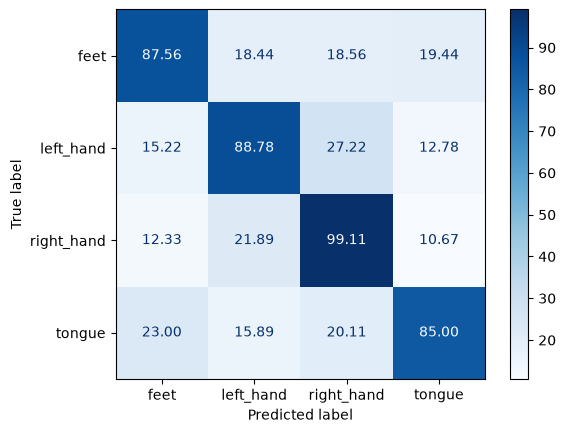

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

fold_results = []
fold_conf_mats = []
num_epochs = 60
batch_size = 32

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\nFold {fold}/{k}")

    X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
    y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    valid_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)


    net = ATCNet(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            n_windows=5,
            attention='mha',
            eegn_F1=32,
            eegn_D=2,
            eegn_kernelSize=32,
            eegn_poolSize=8,
            eegn_dropout=0.5293953079035305,
            tcn_depth=3,
            tcn_kernelSize=5,
            tcn_filters=16,
            tcn_dropout=0.5391932497687246,
            tcn_activation="elu",
            fuse="average",
        ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0010172077937782385
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        net.train()
        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / n_seen

        net.eval()
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / val_seen

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(net.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    metrics = dict(zip(params, evaluate(net, X_va, y_va, params)))
    fold_results.append(metrics)

    net.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
        outputs = net(X_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

    cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
    fold_conf_mats.append(cm)

    print(f"\nFold {fold} Final Validation -")
    print(metrics)


print("\n========== Cross-Validation Results ==========")

avg_metrics = {}
for metric in params:
    values = [result[metric] for result in fold_results]
    avg_metrics[metric] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

avg_cm = np.mean(fold_conf_mats, axis=0)


print("\nAverage Normalized Confusion Matrix:")
print(avg_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format=".2f"
)

plt.show()

[[0.60805556 0.12805556 0.12888889 0.135     ]
 [0.10569444 0.61652778 0.18902778 0.08875   ]
 [0.085625   0.15201389 0.68826389 0.07409722]
 [0.15972222 0.11034722 0.13965278 0.59027778]]


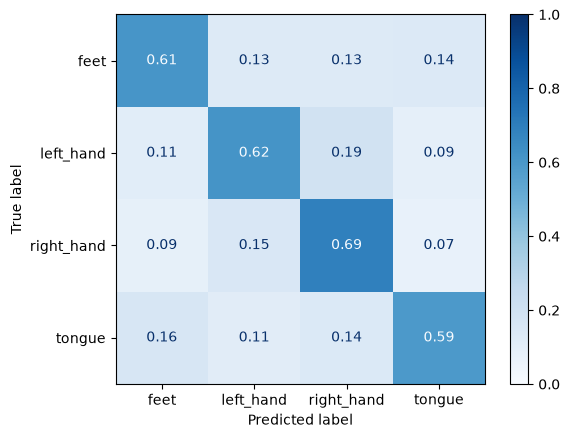

In [22]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Average confusion matrix (raw counts)
cm = np.array([
    [87.56, 18.44, 18.56, 19.44],
    [15.22, 88.78, 27.22, 12.78],
    [12.33, 21.89, 99.11, 10.67],
    [23.00, 15.89, 20.11, 85.00]
])

# Normalize each row
cm_norm = cm / cm.sum(axis=1, keepdims=True)

print(cm_norm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["feet", "left_hand", "right_hand", "tongue"]
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 1},
    values_format=".2f"
)

plt.show()